# Lab: Adversarial Attacks and Adversarial Training


------------------------------------------------------
*Pablo M. Olmos pamartin@ing.uc3m.es*

------------------------------------------------------



## A canonical example: adversarial perturbations

The following figure comes from *Goodfellow et al., 2015* and illustrates how an imperceptible perturbation can completely change a modelâ€™s prediction.

![Adversarial example: panda to gibbon](https://uvadlc-notebooks.readthedocs.io/en/latest/_images/adversarial_example.svg)

From left to right:

- **Original image**: correctly classified as *panda*
- **Adversarial noise**: visually imperceptible (amplified for display in the paper)
- **Adversarial image**: classified as *gibbon* with high confidence

This example highlights that adversarial attacks do not rely on semantic changes, but on exploiting vulnerabilities in the modelâ€™s decision boundaries.


## What is an adversarial example?

An **adversarial example** is a slightly modified input that causes a neural
network to make an incorrect prediction.

Given an input image $x$ and a classifier $f_\theta$, we search for a small
perturbation $\delta$ such that $f_\theta(x) \neq f_\theta(x + \delta)$
while keeping the perturbation imperceptibly small:

$\|\delta\|_\infty \le \varepsilon$

The adversarial image is defined as

$x_{\text{adv}} = \text{clip}(x + \delta)$

where the clipping operation ensures that pixel values remain in the valid
range (e.g. $[0,1]$).


## Threat model: White-box attacks

In this notebook we assume a **white-box attacker**, meaning:

- The model architecture is known
- The model parameters $\theta$ are known
- Gradients $\nabla_x \mathcal{L}(f_\theta(x), y)$ can be computed

This setting allows us to design efficient gradient-based attacks.


## Fast Gradient Sign Method (FGSM)

The **Fast Gradient Sign Method (FGSM)** is a single-step adversarial attack.

Given a loss function $\mathcal{L}$, the perturbation is computed as

$\delta = \varepsilon \cdot \text{sign}\left(\nabla_x \mathcal{L}(f_\theta(x), y)\right)$

The adversarial example is then

$x_{\text{adv}} = \text{clip}(x + \delta)$

Key properties:

- Very fast (one gradient computation)
- Often sufficient to fool standard CNNs
- Serves as the basis for stronger iterative attacks


## Intuition behind FGSM

The gradient $\nabla_x \mathcal{L}(f_\theta(x), y)$ indicates how each pixel
should change to **increase the loss**.

FGSM takes the **sign** of this gradient and pushes each pixel to its maximum
allowed change $\varepsilon$ in the direction that most increases the loss.

Even though the perturbation is small, it is coordinated across all pixels,
which makes it highly effective.


## Projected Gradient Descent (PGD)

**Projected Gradient Descent (PGD)** is an iterative version of FGSM.

Starting from the original image $x^{(0)} = x$, we repeat

$x^{(t+1)} = \Pi_{B_\varepsilon(x)}\left(x^{(t)} + \alpha \cdot \text{sign}\left(\nabla_x \mathcal{L}(f_\theta(x^{(t)}), y)\right)\right)$

where:

- $\alpha$ is the step size
- $\Pi_{B_\varepsilon(x)}$ projects back onto the $\ell_\infty$ ball of radius
  $\varepsilon$ around the original image

PGD is considered a **strong first-order adversary** and is widely used for
robustness evaluation.


### How projection works (intuitively)

For each pixel independently:

- If it lies within the interval $[x_i - \varepsilon,\; x_i + \varepsilon]$, it is left unchanged.
- If it is larger than $x_i + \varepsilon$, it is clamped down to $x_i + \varepsilon$.
- If it is smaller than $x_i - \varepsilon$, it is clamped up to $x_i - \varepsilon$.

As a result, the projection step is simply an element-wise clipping operation that keeps the adversarial example within an $\ell_\infty$ distance $\varepsilon$ of the original image.


## Targeted vs untargeted attacks

### Untargeted attack

The goal is simply to cause **any misclassification**:

$\max_\delta \; \mathcal{L}(f_\theta(x + \delta), y)$

### Targeted attack

The goal is to force the model to predict a **specific target class**
$y_{\text{target}}$:

$\min_\delta \; \mathcal{L}(f_\theta(x + \delta), y_{\text{target}})$

Targeted attacks are typically harder and require stronger perturbations or
more iterations.


## Accuracy vs perturbation strength

A common way to evaluate adversarial robustness is to measure test accuracy
as a function of $\varepsilon$:

- $\varepsilon = 0$: clean accuracy
- Increasing $\varepsilon$: stronger attacks
- Rapid accuracy drop indicates lack of robustness

This evaluation helps visualize how fragile standard CNNs are to adversarial
perturbations.


## Key takeaways

- Adversarial examples exploit the **local linearity** of neural networks
- FGSM is fast and simple but already very effective
- PGD is stronger and often considered the "gold standard" attack
- Standard CNNs trained normally are **not robust** to adversarial noise

Adversarial robustness is an important consideration when deploying deep
learning models in safety-critical applications.


## Setup (GPU)

This notebook will use **one GPU** if available. We set `CUDA_VISIBLE_DEVICES=0` and use `cuda:0`.


In [37]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Use one GPU if available.
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")


def set_seed(seed=0):
    """
    High-level overview:
    Set random seeds so runs are easier to reproduce.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(0)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.cuda.set_device(0)
    torch.backends.cudnn.benchmark = True
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")


Using GPU: NVIDIA GeForce RTX 3050 4GB Laptop GPU


# Part I: CIFAR-10 Dataset and Preprocessing

The project instructions say to use the same dataset and preprocessing as the class notebook: **CIFAR-10** with images kept in the `[0, 1]` range. This notebook therefore uses CIFAR-10 for the main experiments and does not train on MNIST.


In [38]:
batch_size = 128

# Keep CIFAR-10 images in [0, 1]. This matches the attack code, which clips
# adversarial images back into the valid pixel range.
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_ds = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_ds = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

pin_memory = device.type == "cuda"
num_workers = 4 if os.name != "nt" else 0
num_workers = min(num_workers, os.cpu_count() or 2)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=(num_workers > 0),
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=(num_workers > 0),
)

classes = train_ds.classes
x0, y0 = next(iter(train_loader))
print("Batch:", x0.shape, y0.shape)
print("Classes:", classes)


c:\Users\Andrew\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Batch: torch.Size([128, 3, 32, 32]) torch.Size([128])
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


# Part II: Shared Training, Attacks, and Calibration Helpers

These functions are used by both the small CNN and the larger CNN. Keeping them here avoids repeating the same training, attack, metric, and plotting code in both experiment sections.


In [39]:
def train_one_epoch(model, loader, optimizer):
    """
    High-level overview:
    Train the model for one epoch on clean CIFAR-10 images.
    """
    model.train()
    total_loss, total = 0.0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total += x.size(0)

    return total_loss / total


@torch.no_grad()
def eval_clean_accuracy(model, loader):
    """
    High-level overview:
    Measure accuracy on clean test images.
    """
    model.eval()
    correct, total = 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total += x.size(0)

    return correct / total


def clamp01(x):
    """
    High-level overview:
    Keep image values between 0 and 1.
    """
    return torch.clamp(x, 0.0, 1.0)


def fgsm_attack(model, x, y, eps):
    """
    High-level overview:
    Create adversarial images using one gradient step.
    """
    model.eval()
    x_adv = x.clone().detach().requires_grad_(True)
    logits = model(x_adv)
    loss = F.cross_entropy(logits, y)
    grad_sign = torch.autograd.grad(loss, x_adv)[0].sign()
    x_adv = x_adv + eps * grad_sign
    return clamp01(x_adv.detach())


def pgd_attack(model, x, y, eps, alpha, steps, random_start=True):
    """
    High-level overview:
    Create adversarial images using many small gradient steps.
    """
    model.eval()
    x_orig = x.detach()

    if random_start:
        x_adv = x_orig + (2 * torch.rand_like(x_orig) - 1.0) * eps
        x_adv = clamp01(x_adv)
    else:
        x_adv = x_orig.clone()

    for _ in range(steps):
        x_adv = x_adv.clone().detach().requires_grad_(True)
        logits = model(x_adv)
        loss = F.cross_entropy(logits, y)
        grad = torch.autograd.grad(loss, x_adv)[0]
        x_adv = x_adv + alpha * grad.sign()

        delta = torch.clamp(x_adv - x_orig, min=-eps, max=eps)
        x_adv = clamp01(x_orig + delta)

    return x_adv.detach()


def train_one_epoch_adv_fgsm(model, loader, optimizer, eps):
    """
    High-level overview:
    Train for one epoch using FGSM adversarial examples.
    """
    model.train()
    total_loss, total = 0.0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # Build FGSM examples with the current model, then optimize on them.
        x_adv = fgsm_attack(model, x, y, eps=eps)

        optimizer.zero_grad(set_to_none=True)
        logits_adv = model(x_adv)
        loss = F.cross_entropy(logits_adv, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total += x.size(0)

    return total_loss / total


In [40]:
def collect_logits_and_labels(model, loader, attack_fn=None, max_batches=None):
    """
    High-level overview:
    Collect model outputs and labels for metric calculations.
    """
    model.eval()
    logits_list, labels_list = [], []

    for batch_idx, (x, y) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        x_eval = attack_fn(x, y) if attack_fn is not None else x

        with torch.no_grad():
            logits = model(x_eval)

        logits_list.append(logits.cpu())
        labels_list.append(y.cpu())

    return torch.cat(logits_list), torch.cat(labels_list)


def compute_nll(logits, labels):
    """
    High-level overview:
    Compute negative log-likelihood.
    """
    return F.cross_entropy(logits, labels).item()


def compute_ece(logits, labels, n_bins=15):
    """
    High-level overview:
    Measure how close confidence is to real accuracy.
    """
    probs = torch.softmax(logits, dim=1)
    confidences, predictions = probs.max(dim=1)
    accuracies = predictions.eq(labels)
    bin_edges = torch.linspace(0.0, 1.0, steps=n_bins + 1)
    ece = torch.zeros(1)

    for bin_idx in range(n_bins):
        lower = bin_edges[bin_idx]
        upper = bin_edges[bin_idx + 1]
        if bin_idx == n_bins - 1:
            in_bin = (confidences >= lower) & (confidences <= upper)
        else:
            in_bin = (confidences >= lower) & (confidences < upper)

        prop_in_bin = in_bin.float().mean()
        if prop_in_bin.item() > 0:
            acc_in_bin = accuracies[in_bin].float().mean()
            conf_in_bin = confidences[in_bin].mean()
            ece += torch.abs(conf_in_bin - acc_in_bin) * prop_in_bin

    return ece.item()


def metric_dict(logits, labels):
    """
    High-level overview:
    Return accuracy, NLL, and ECE from logits and labels.
    """
    preds = logits.argmax(1)
    return {
        "accuracy": preds.eq(labels).float().mean().item(),
        "nll": compute_nll(logits, labels),
        "ece": compute_ece(logits, labels),
    }


def reliability_diagram_from_logits(logits, labels, n_bins=15, ax=None, title="Reliability diagram"):
    """
    High-level overview:
    Draw a reliability diagram from model outputs.
    """
    probs = torch.softmax(logits, dim=1)
    confidences, predictions = probs.max(dim=1)
    accuracies = predictions.eq(labels)
    bin_edges = torch.linspace(0.0, 1.0, steps=n_bins + 1)

    centers, bin_accs, bin_confs = [], [], []
    for bin_idx in range(n_bins):
        lower = bin_edges[bin_idx]
        upper = bin_edges[bin_idx + 1]
        if bin_idx == n_bins - 1:
            in_bin = (confidences >= lower) & (confidences <= upper)
        else:
            in_bin = (confidences >= lower) & (confidences < upper)

        if in_bin.any():
            centers.append(((lower + upper) / 2).item())
            bin_accs.append(accuracies[in_bin].float().mean().item())
            bin_confs.append(confidences[in_bin].mean().item())

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
    ax.bar(centers, bin_accs, width=1.0 / n_bins, alpha=0.6, edgecolor="black", label="Accuracy")
    ax.plot(centers, bin_confs, marker="o", color="tab:red", label="Confidence")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    return ax


In [41]:
# CIFAR-10 epsilon values. 8/255 is a common maximum perturbation budget.
eps_list = [0.0, 0.5 / 255, 1 / 255, 2 / 255, 4 / 255, 8 / 255]
pgd_steps = 10
max_eval_batches = None  # Set to a small number while debugging if needed.


def evaluate_model_over_eps(model, loader, model_name, training_name, eps_values, pgd_steps=10, max_batches=None):
    """
    High-level overview:
    Evaluate clean, FGSM, and PGD metrics across epsilon values.
    """
    rows = []

    for eps in eps_values:
        clean_logits, clean_labels = collect_logits_and_labels(model, loader, attack_fn=None, max_batches=max_batches)
        clean_metrics = metric_dict(clean_logits, clean_labels)
        rows.append({
            "model": model_name,
            "training": training_name,
            "epsilon": float(eps),
            "attack": "Clean",
            **clean_metrics,
        })

        if eps == 0.0:
            continue

        fgsm_logits, fgsm_labels = collect_logits_and_labels(
            model,
            loader,
            attack_fn=lambda x, y, eps=eps: fgsm_attack(model, x, y, eps=eps),
            max_batches=max_batches,
        )
        rows.append({
            "model": model_name,
            "training": training_name,
            "epsilon": float(eps),
            "attack": "FGSM",
            **metric_dict(fgsm_logits, fgsm_labels),
        })

        pgd_logits, pgd_labels = collect_logits_and_labels(
            model,
            loader,
            attack_fn=lambda x, y, eps=eps: pgd_attack(
                model,
                x,
                y,
                eps=eps,
                alpha=eps / 4,
                steps=pgd_steps,
                random_start=True,
            ),
            max_batches=max_batches,
        )
        rows.append({
            "model": model_name,
            "training": training_name,
            "epsilon": float(eps),
            "attack": f"PGD-{pgd_steps}",
            **metric_dict(pgd_logits, pgd_labels),
        })

    return pd.DataFrame(rows)


def plot_epsilon_results(df, title):
    """
    High-level overview:
    Plot ECE, clean accuracy, and robust accuracy versus epsilon.
    """
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

    for training_name in df["training"].unique():
        clean = df[(df["training"] == training_name) & (df["attack"] == "Clean")].sort_values("epsilon")
        axes[0].plot(clean["epsilon"], clean["ece"], marker="o", label=f"{training_name} clean")
        axes[1].plot(clean["epsilon"], clean["accuracy"], marker="o", label=f"{training_name} clean")

        for attack_name in ["FGSM", f"PGD-{pgd_steps}"]:
            sub = df[(df["training"] == training_name) & (df["attack"] == attack_name)].sort_values("epsilon")
            axes[0].plot(sub["epsilon"], sub["ece"], marker="o", label=f"{training_name} {attack_name}")
            axes[2].plot(sub["epsilon"], sub["accuracy"], marker="o", label=f"{training_name} {attack_name}")

    axes[0].set_title("ECE vs epsilon")
    axes[0].set_xlabel("epsilon")
    axes[0].set_ylabel("ECE")
    axes[1].set_title("Clean accuracy vs epsilon")
    axes[1].set_xlabel("epsilon")
    axes[1].set_ylabel("Clean accuracy")
    axes[2].set_title("Robust accuracy vs epsilon")
    axes[2].set_xlabel("epsilon")
    axes[2].set_ylabel("Robust accuracy")

    for ax in axes:
        ax.grid(True)
        ax.legend(fontsize=8)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_reliability_for_eps(model, loader, eps, title_prefix, pgd_steps=10, max_batches=None):
    """
    High-level overview:
    Plot reliability diagrams for clean, FGSM, and PGD inputs.
    """
    settings = [
        ("Clean", None),
        (f"FGSM eps={eps:.4f}", lambda x, y: fgsm_attack(model, x, y, eps=eps)),
        (f"PGD-{pgd_steps} eps={eps:.4f}", lambda x, y: pgd_attack(model, x, y, eps=eps, alpha=eps / 4, steps=pgd_steps)),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, (name, attack_fn) in zip(axes, settings):
        logits, labels = collect_logits_and_labels(model, loader, attack_fn=attack_fn, max_batches=max_batches)
        reliability_diagram_from_logits(logits, labels, ax=ax, title=f"{title_prefix}: {name}")
    plt.tight_layout()
    plt.show()


# Part III: Small CNN Experiments

Everything in this section uses the small CIFAR-10 CNN. First we train it normally with cross-entropy, then we evaluate clean accuracy, FGSM/PGD robust accuracy, ECE, NLL, and reliability diagrams. After that, we train the same architecture with FGSM adversarial training and repeat the same evaluation.


## Part III.A: Small CNN Architecture


In [42]:
class SmallCIFARCNN(nn.Module):
    def __init__(self, num_classes=10):
        """
        High-level overview:
        Build the small CIFAR-10 CNN used in the main experiment.
        """
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.fc1 = nn.Linear(256 * 2 * 2, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        """
        High-level overview:
        Run a CIFAR-10 image through the small CNN and return class scores.
        """
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)   # 32 -> 16
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)   # 16 -> 8
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)   # 8 -> 4
        x = F.relu(self.conv4(x))
        x = F.max_pool2d(x, 2)   # 4 -> 2
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


## Part III.B: Standard Training for the Small CNN


In [43]:
small_model = SmallCIFARCNN().to(device)
small_opt = torch.optim.Adam(small_model.parameters(), lr=1e-3)
small_epochs = 5

for epoch in range(small_epochs):
    loss = train_one_epoch(small_model, train_loader, small_opt)
    clean_acc = eval_clean_accuracy(small_model, test_loader)
    print(f"[small-standard] epoch={epoch+1} loss={loss:.4f} clean_test_acc={clean_acc*100:.2f}%")


[small-standard] epoch=1 loss=1.5992 clean_test_acc=53.72%
[small-standard] epoch=2 loss=1.1540 clean_test_acc=62.74%
[small-standard] epoch=3 loss=0.9316 clean_test_acc=69.54%
[small-standard] epoch=4 loss=0.7836 clean_test_acc=71.49%
[small-standard] epoch=5 loss=0.6812 clean_test_acc=74.16%


## Part III.C: Standard Small CNN Evaluation

This cell keeps the required plots: ECE vs epsilon, clean accuracy vs epsilon, and robust accuracy under FGSM and PGD vs epsilon.


,model,training,epsilon,attack,accuracy,nll,ece
0,Small CNN,Standard,0.00000,Clean,0.7416,0.7590,0.0157
1,Small CNN,Standard,0.00196,Clean,0.7416,0.7590,0.0157
2,Small CNN,Standard,0.00196,FGSM,0.6602,0.9837,0.0629
3,Small CNN,Standard,0.00196,PGD-10,0.6565,0.9918,0.0672
4,Small CNN,Standard,0.00392,Clean,0.7416,0.7590,0.0157
5,Small CNN,Standard,0.00392,FGSM,0.5768,1.2347,0.1282
6,Small CNN,Standard,0.00392,PGD-10,0.5623,1.2723,0.1449
7,Small CNN,Standard,0.00784,Clean,0.7416,0.7590,0.0157
8,Small CNN,Standard,0.00784,FGSM,0.4241,1.7886,0.2651
9,Small CNN,Standard,0.00784,PGD-10,0.3767,1.9738,0.3312


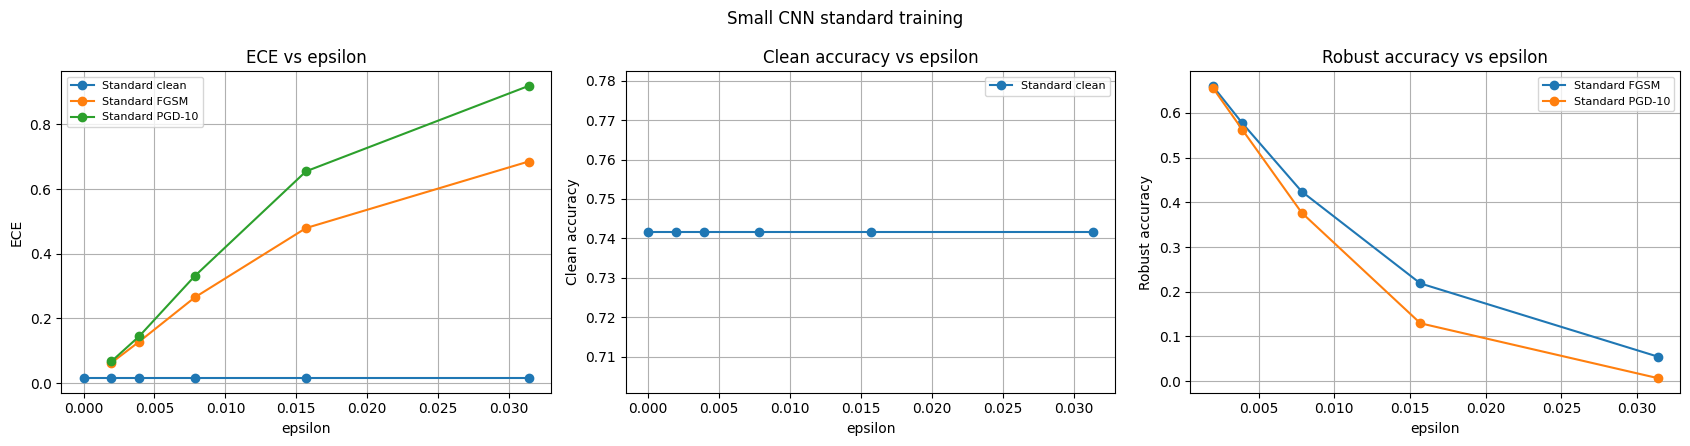

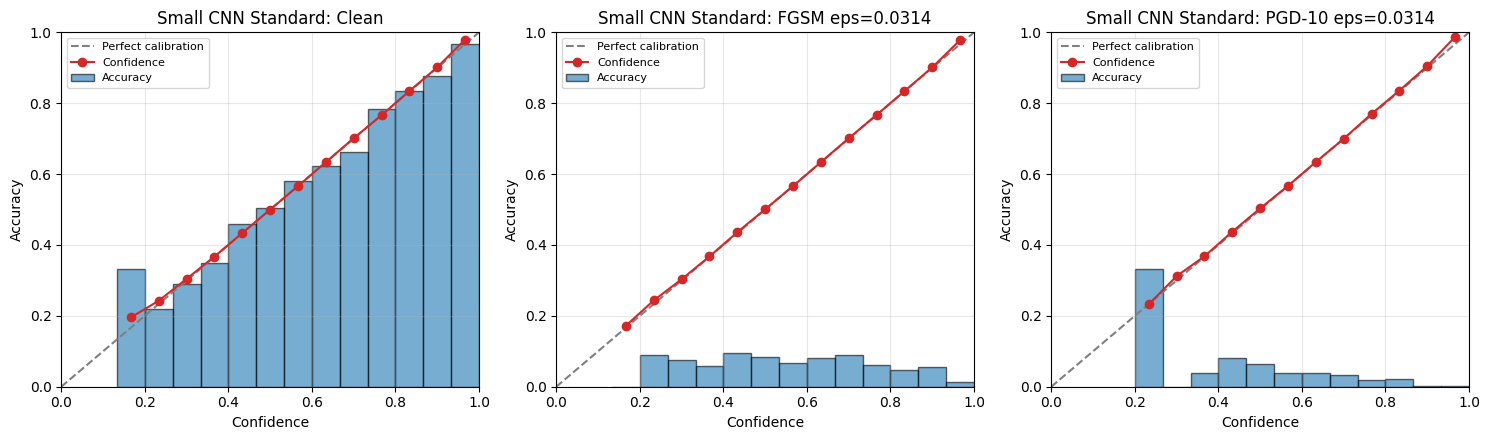

In [44]:
small_standard_df = evaluate_model_over_eps(
    small_model,
    test_loader,
    model_name="Small CNN",
    training_name="Standard",
    eps_values=eps_list,
    pgd_steps=pgd_steps,
    max_batches=max_eval_batches,
)

display(small_standard_df.style.format({
    "epsilon": "{:.5f}",
    "accuracy": "{:.4f}",
    "nll": "{:.4f}",
    "ece": "{:.4f}",
}))

plot_epsilon_results(small_standard_df, "Small CNN standard training")
plot_reliability_for_eps(small_model, test_loader, eps=8 / 255, title_prefix="Small CNN Standard", pgd_steps=pgd_steps, max_batches=max_eval_batches)


## Part III.D: FGSM Adversarial Training for the Small CNN


In [45]:
small_adv_model = SmallCIFARCNN().to(device)
small_adv_opt = torch.optim.Adam(small_adv_model.parameters(), lr=1e-3)
adv_train_eps = 8 / 255
small_adv_epochs = 5

for epoch in range(small_adv_epochs):
    loss = train_one_epoch_adv_fgsm(small_adv_model, train_loader, small_adv_opt, eps=adv_train_eps)
    clean_acc = eval_clean_accuracy(small_adv_model, test_loader)
    print(f"[small-fgsm-at] epoch={epoch+1} loss={loss:.4f} clean_test_acc={clean_acc*100:.2f}%")


[small-fgsm-at] epoch=1 loss=2.0951 clean_test_acc=41.98%
[small-fgsm-at] epoch=2 loss=1.8916 clean_test_acc=47.72%
[small-fgsm-at] epoch=3 loss=1.8175 clean_test_acc=50.75%
[small-fgsm-at] epoch=4 loss=1.7627 clean_test_acc=54.26%
[small-fgsm-at] epoch=5 loss=1.7216 clean_test_acc=54.75%


## Part III.E: Adversarially Trained Small CNN Evaluation

This repeats the same evaluation pipeline for the FGSM-adversarially trained small CNN and keeps the required epsilon plots.


,model,training,epsilon,attack,accuracy,nll,ece
0,Small CNN,FGSM AT,0.00000,Clean,0.5475,1.3270,0.1471
1,Small CNN,FGSM AT,0.00196,Clean,0.5475,1.3270,0.1471
2,Small CNN,FGSM AT,0.00196,FGSM,0.5309,1.3534,0.1337
3,Small CNN,FGSM AT,0.00196,PGD-10,0.5305,1.3537,0.1333
4,Small CNN,FGSM AT,0.00392,Clean,0.5475,1.3270,0.1471
5,Small CNN,FGSM AT,0.00392,FGSM,0.5184,1.3797,0.1241
6,Small CNN,FGSM AT,0.00392,PGD-10,0.5176,1.3809,0.1236
7,Small CNN,FGSM AT,0.00784,Clean,0.5475,1.3270,0.1471
8,Small CNN,FGSM AT,0.00784,FGSM,0.4889,1.4323,0.1008
9,Small CNN,FGSM AT,0.00784,PGD-10,0.4863,1.4370,0.0985


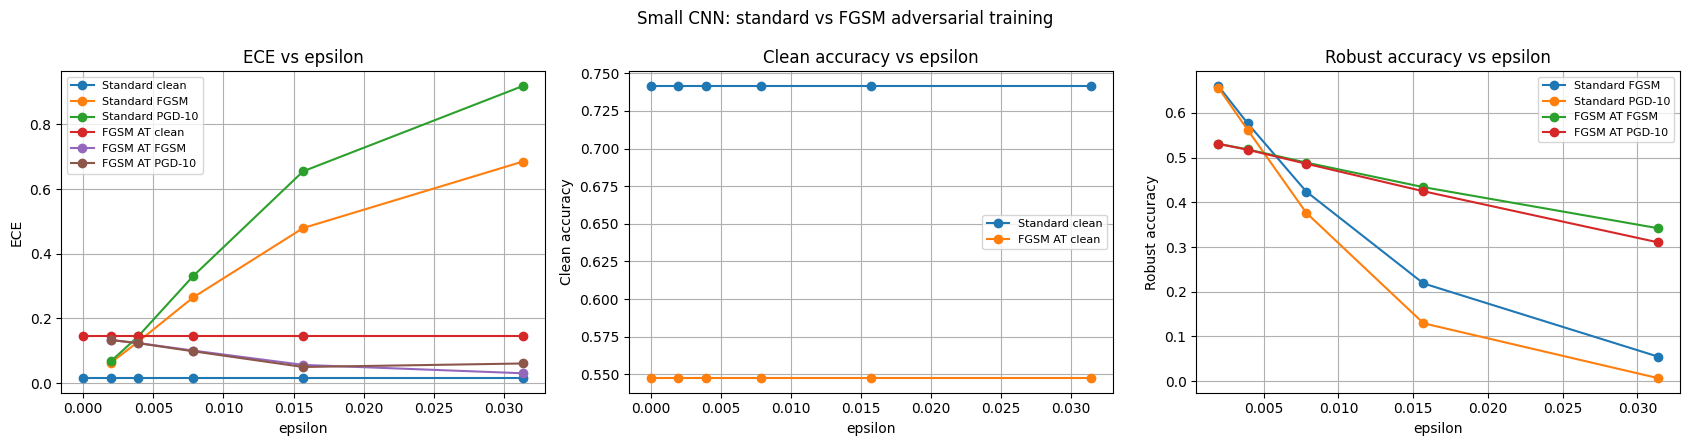

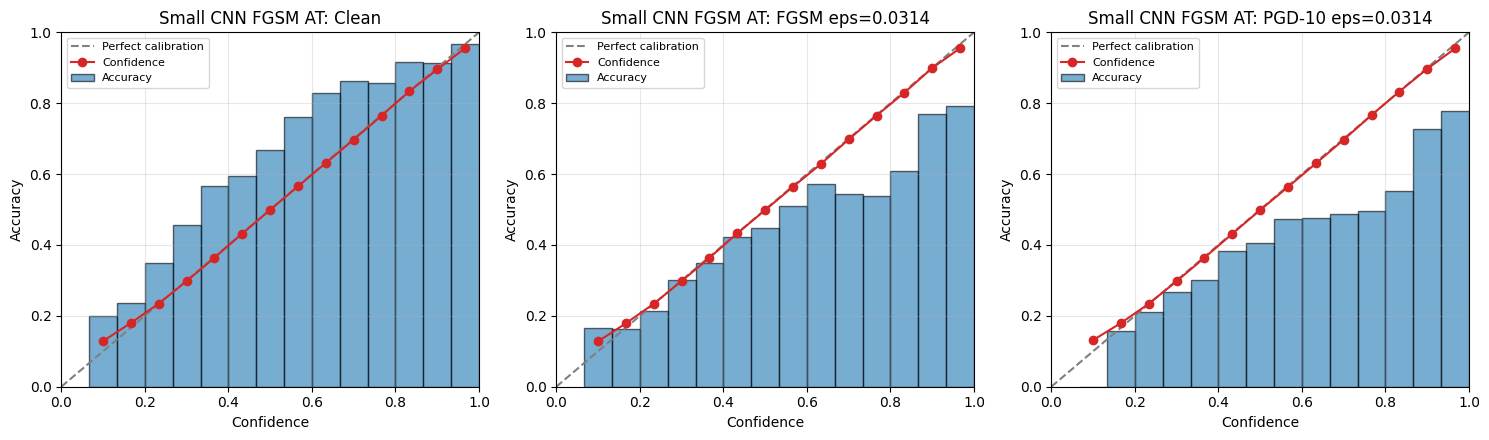

In [46]:
small_adv_df = evaluate_model_over_eps(
    small_adv_model,
    test_loader,
    model_name="Small CNN",
    training_name="FGSM AT",
    eps_values=eps_list,
    pgd_steps=pgd_steps,
    max_batches=max_eval_batches,
)

display(small_adv_df.style.format({
    "epsilon": "{:.5f}",
    "accuracy": "{:.4f}",
    "nll": "{:.4f}",
    "ece": "{:.4f}",
}))

small_compare_df = pd.concat([small_standard_df, small_adv_df], ignore_index=True)
plot_epsilon_results(small_compare_df, "Small CNN: standard vs FGSM adversarial training")
plot_reliability_for_eps(small_adv_model, test_loader, eps=8 / 255, title_prefix="Small CNN FGSM AT", pgd_steps=pgd_steps, max_batches=max_eval_batches)


## Part III.F: Small CNN Standard vs FGSM-AT Summary


In [47]:
def summarize_at_effect(df, model_name, eps):
    """
    High-level overview:
    Compare standard training and FGSM adversarial training at one epsilon.
    """
    sub = df[df["epsilon"].round(8) == round(float(eps), 8)]
    rows = []

    for attack_name in ["Clean", "FGSM", f"PGD-{pgd_steps}"]:
        attack_sub = sub[sub["attack"] == attack_name]
        if attack_sub.empty:
            continue
        std = attack_sub[attack_sub["training"] == "Standard"].iloc[0]
        adv = attack_sub[attack_sub["training"] == "FGSM AT"].iloc[0]
        rows.append({
            "model": model_name,
            "epsilon": eps,
            "attack": attack_name,
            "standard_accuracy": std["accuracy"],
            "fgsm_at_accuracy": adv["accuracy"],
            "accuracy_change": adv["accuracy"] - std["accuracy"],
            "standard_ece": std["ece"],
            "fgsm_at_ece": adv["ece"],
            "ece_change": adv["ece"] - std["ece"],
            "standard_nll": std["nll"],
            "fgsm_at_nll": adv["nll"],
            "nll_change": adv["nll"] - std["nll"],
        })

    return pd.DataFrame(rows)


small_at_summary = summarize_at_effect(small_compare_df, "Small CNN", eps=8 / 255)
display(small_at_summary.style.format({
    "epsilon": "{:.5f}",
    "standard_accuracy": "{:.4f}",
    "fgsm_at_accuracy": "{:.4f}",
    "accuracy_change": "{:+.4f}",
    "standard_ece": "{:.4f}",
    "fgsm_at_ece": "{:.4f}",
    "ece_change": "{:+.4f}",
    "standard_nll": "{:.4f}",
    "fgsm_at_nll": "{:.4f}",
    "nll_change": "{:+.4f}",
}))


,model,epsilon,attack,standard_accuracy,fgsm_at_accuracy,accuracy_change,standard_ece,fgsm_at_ece,ece_change,standard_nll,fgsm_at_nll,nll_change
0,Small CNN,0.03137,Clean,0.7416,0.5475,-0.1941,0.0157,0.1471,+0.1314,0.7590,1.3270,+0.5680
1,Small CNN,0.03137,FGSM,0.0550,0.3421,+0.2871,0.6850,0.0306,-0.6544,4.9455,1.7488,-3.1967
2,Small CNN,0.03137,PGD-10,0.0069,0.3105,+0.3036,0.9186,0.0609,-0.8577,8.0789,1.8275,-6.2514


# Part IV: Larger CNN Experiments

This section repeats the same workflow with the larger CIFAR-10 CNN. The order mirrors the small-CNN section: define the architecture, train normally, evaluate, train with FGSM adversarial training, and evaluate again.


## Part IV.A: Larger CNN Architecture


In [48]:
class LargeCIFARCNN(nn.Module):
    def __init__(self, num_classes=10):
        """
        High-level overview:
        Build a larger CIFAR-10 CNN for the model-scaling experiment.
        """
        super().__init__()
        self.conv1 = nn.Conv2d(3, 96, 3, padding=1)
        self.conv2 = nn.Conv2d(96, 192, 3, padding=1)
        self.conv3 = nn.Conv2d(192, 256, 3, padding=1)
        self.conv4 = nn.Conv2d(256, 384, 3, padding=1)
        self.conv5 = nn.Conv2d(384, 384, 3, padding=1)
        self.fc1 = nn.Linear(384 * 1 * 1, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        """
        High-level overview:
        Run a CIFAR-10 image through the larger CNN and return class scores.
        """
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)   # 32 -> 16
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)   # 16 -> 8
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)   # 8 -> 4
        x = F.relu(self.conv4(x))
        x = F.max_pool2d(x, 2)   # 4 -> 2
        x = F.relu(self.conv5(x))
        x = F.max_pool2d(x, 2)   # 2 -> 1
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


## Part IV.B: Standard Training for the Larger CNN


In [49]:
large_model = LargeCIFARCNN().to(device)
large_opt = torch.optim.Adam(large_model.parameters(), lr=1e-3)
large_epochs = 5

for epoch in range(large_epochs):
    loss = train_one_epoch(large_model, train_loader, large_opt)
    clean_acc = eval_clean_accuracy(large_model, test_loader)
    print(f"[large-standard] epoch={epoch+1} loss={loss:.4f} clean_test_acc={clean_acc*100:.2f}%")


[large-standard] epoch=1 loss=1.6783 clean_test_acc=49.89%
[large-standard] epoch=2 loss=1.1897 clean_test_acc=61.10%
[large-standard] epoch=3 loss=0.9500 clean_test_acc=67.98%
[large-standard] epoch=4 loss=0.7843 clean_test_acc=71.37%
[large-standard] epoch=5 loss=0.6517 clean_test_acc=72.88%


## Part IV.C: Standard Larger CNN Evaluation

This cell keeps the required plots: ECE vs epsilon, clean accuracy vs epsilon, and robust accuracy under FGSM and PGD vs epsilon.


,model,training,epsilon,attack,accuracy,nll,ece
0,Large CNN,Standard,0.00000,Clean,0.7288,0.7953,0.0236
1,Large CNN,Standard,0.00196,Clean,0.7288,0.7953,0.0236
2,Large CNN,Standard,0.00196,FGSM,0.6298,1.0708,0.0949
3,Large CNN,Standard,0.00196,PGD-10,0.6240,1.0845,0.1007
4,Large CNN,Standard,0.00392,Clean,0.7288,0.7953,0.0236
5,Large CNN,Standard,0.00392,FGSM,0.5384,1.3730,0.1711
6,Large CNN,Standard,0.00392,PGD-10,0.5163,1.4377,0.1970
7,Large CNN,Standard,0.00784,Clean,0.7288,0.7953,0.0236
8,Large CNN,Standard,0.00784,FGSM,0.3829,2.0072,0.3162
9,Large CNN,Standard,0.00784,PGD-10,0.3224,2.3186,0.4070


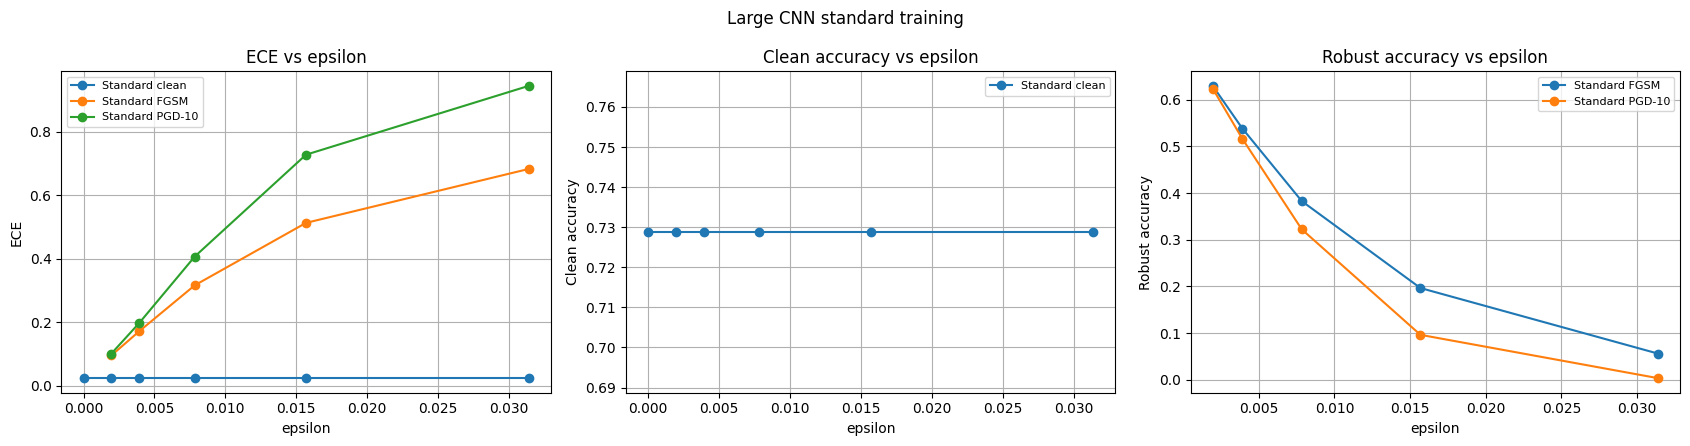

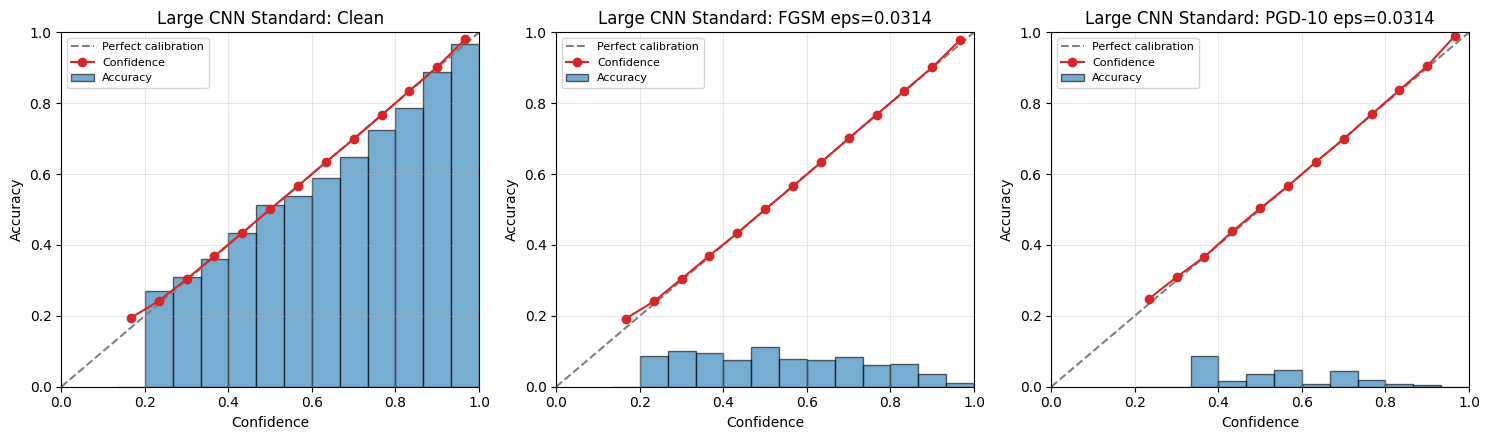

In [50]:
large_standard_df = evaluate_model_over_eps(
    large_model,
    test_loader,
    model_name="Large CNN",
    training_name="Standard",
    eps_values=eps_list,
    pgd_steps=pgd_steps,
    max_batches=max_eval_batches,
)

display(large_standard_df.style.format({
    "epsilon": "{:.5f}",
    "accuracy": "{:.4f}",
    "nll": "{:.4f}",
    "ece": "{:.4f}",
}))

plot_epsilon_results(large_standard_df, "Large CNN standard training")
plot_reliability_for_eps(large_model, test_loader, eps=8 / 255, title_prefix="Large CNN Standard", pgd_steps=pgd_steps, max_batches=max_eval_batches)


## Part IV.D: FGSM Adversarial Training for the Larger CNN


In [51]:
large_adv_model = LargeCIFARCNN().to(device)
large_adv_opt = torch.optim.Adam(large_adv_model.parameters(), lr=1e-3)
large_adv_epochs = 5

for epoch in range(large_adv_epochs):
    loss = train_one_epoch_adv_fgsm(large_adv_model, train_loader, large_adv_opt, eps=adv_train_eps)
    clean_acc = eval_clean_accuracy(large_adv_model, test_loader)
    print(f"[large-fgsm-at] epoch={epoch+1} loss={loss:.4f} clean_test_acc={clean_acc*100:.2f}%")


[large-fgsm-at] epoch=1 loss=2.0973 clean_test_acc=39.42%
[large-fgsm-at] epoch=2 loss=1.9058 clean_test_acc=46.10%
[large-fgsm-at] epoch=3 loss=1.8273 clean_test_acc=47.87%
[large-fgsm-at] epoch=4 loss=1.7747 clean_test_acc=50.57%
[large-fgsm-at] epoch=5 loss=1.7290 clean_test_acc=53.06%


## Part IV.E: Adversarially Trained Larger CNN Evaluation

This repeats the same evaluation pipeline for the FGSM-adversarially trained larger CNN and keeps the required epsilon plots.


,model,training,epsilon,attack,accuracy,nll,ece
0,Large CNN,FGSM AT,0.00000,Clean,0.5306,1.3367,0.1334
1,Large CNN,FGSM AT,0.00196,Clean,0.5306,1.3367,0.1334
2,Large CNN,FGSM AT,0.00196,FGSM,0.5177,1.3613,0.1236
3,Large CNN,FGSM AT,0.00196,PGD-10,0.5176,1.3616,0.1235
4,Large CNN,FGSM AT,0.00392,Clean,0.5306,1.3367,0.1334
5,Large CNN,FGSM AT,0.00392,FGSM,0.5052,1.3858,0.1140
6,Large CNN,FGSM AT,0.00392,PGD-10,0.5048,1.3869,0.1137
7,Large CNN,FGSM AT,0.00784,Clean,0.5306,1.3367,0.1334
8,Large CNN,FGSM AT,0.00784,FGSM,0.4805,1.4348,0.0944
9,Large CNN,FGSM AT,0.00784,PGD-10,0.4786,1.4393,0.0930


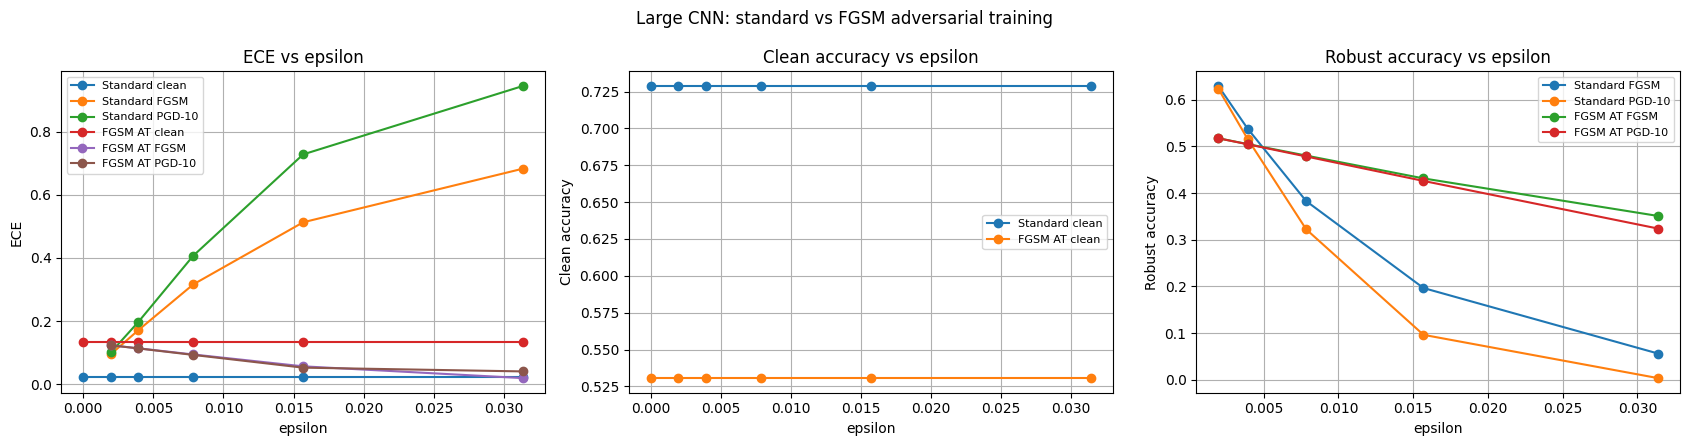

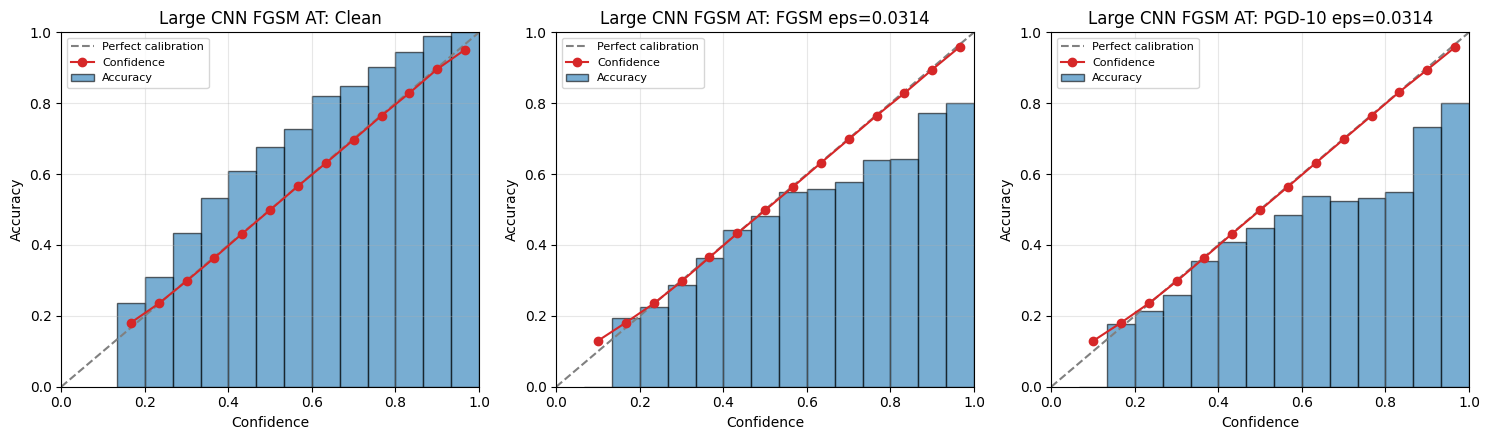

,model,epsilon,attack,standard_accuracy,fgsm_at_accuracy,accuracy_change,standard_ece,fgsm_at_ece,ece_change,standard_nll,fgsm_at_nll,nll_change
0,Large CNN,0.03137,Clean,0.7288,0.5306,-0.1982,0.0236,0.1334,+0.1098,0.7953,1.3367,+0.5414
1,Large CNN,0.03137,FGSM,0.0562,0.3511,+0.2949,0.6830,0.0196,-0.6634,4.8573,1.7316,-3.1257
2,Large CNN,0.03137,PGD-10,0.0035,0.3241,+0.3206,0.9449,0.0408,-0.9041,9.1360,1.8101,-7.3259


In [52]:
large_adv_df = evaluate_model_over_eps(
    large_adv_model,
    test_loader,
    model_name="Large CNN",
    training_name="FGSM AT",
    eps_values=eps_list,
    pgd_steps=pgd_steps,
    max_batches=max_eval_batches,
)

display(large_adv_df.style.format({
    "epsilon": "{:.5f}",
    "accuracy": "{:.4f}",
    "nll": "{:.4f}",
    "ece": "{:.4f}",
}))

large_compare_df = pd.concat([large_standard_df, large_adv_df], ignore_index=True)
plot_epsilon_results(large_compare_df, "Large CNN: standard vs FGSM adversarial training")
plot_reliability_for_eps(large_adv_model, test_loader, eps=8 / 255, title_prefix="Large CNN FGSM AT", pgd_steps=pgd_steps, max_batches=max_eval_batches)

large_at_summary = summarize_at_effect(large_compare_df, "Large CNN", eps=8 / 255)
display(large_at_summary.style.format({
    "epsilon": "{:.5f}",
    "standard_accuracy": "{:.4f}",
    "fgsm_at_accuracy": "{:.4f}",
    "accuracy_change": "{:+.4f}",
    "standard_ece": "{:.4f}",
    "fgsm_at_ece": "{:.4f}",
    "ece_change": "{:+.4f}",
    "standard_nll": "{:.4f}",
    "fgsm_at_nll": "{:.4f}",
    "nll_change": "{:+.4f}",
}))
